# Visualizacao da saida `t2mgpt` em video no Jupyter

Este notebook carrega uma amostra de `output/robot_emotions_t2mgpt`, mostra os metadados do manifesto e renderiza a sequencia 3D inline em `.mp4`.

Diferente do `smplx_video_notebook.ipynb`, aqui a saida disponivel e um `pose3d.npz` no contrato `PoseSequence3D` (22 joints IMUGPT22). Por isso a visualizacao renderiza o esqueleto 3D diretamente, em vez de uma malha SMPL-X.


In [1]:
# Instale as dependencias se necessario.
%pip install -q numpy matplotlib imageio imageio-ffmpeg ipython


Note: you may need to restart the kernel to use updated packages.


In [2]:
from __future__ import annotations

from collections import Counter
from pathlib import Path
import json
import textwrap

import imageio.v2 as imageio
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Video, display

np.set_printoptions(precision=4, suppress=True)
plt.rcParams['figure.figsize'] = (8, 8)
plt.rcParams['axes.grid'] = False

DEFAULT_IMUGPT22_JOINT_NAMES = (
    'Pelvis',
    'Left_hip',
    'Right_hip',
    'Spine1',
    'Left_knee',
    'Right_knee',
    'Spine2',
    'Left_ankle',
    'Right_ankle',
    'Spine3',
    'Left_foot',
    'Right_foot',
    'Neck',
    'Left_collar',
    'Right_collar',
    'Head',
    'Left_shoulder',
    'Right_shoulder',
    'Left_elbow',
    'Right_elbow',
    'Left_wrist',
    'Right_wrist',
)

DEFAULT_IMUGPT22_PARENT_INDICES = (
    -1,
    0,
    0,
    0,
    1,
    2,
    3,
    4,
    5,
    6,
    7,
    8,
    9,
    9,
    9,
    12,
    13,
    14,
    16,
    17,
    18,
    19,
)

POSE_VARIANT_ARTIFACT_KEYS = {
    'pose3d': 'pose3d_npz_path',
    'metric_local': 'pose3d_metric_local_npz_path',
    'prompt_raw': 'pose3d_prompt_raw_npz_path',
}


In [3]:
ROOT_DIR = Path.cwd()
OUTPUT_ROOT = ROOT_DIR / 'output' / 'robot_emotions_t2mgpt'
MANIFEST_PATH = OUTPUT_ROOT / 'prompt_pose3d_manifest.jsonl'
SUMMARY_PATH = OUTPUT_ROOT / 'prompt_pose3d_summary.json'

DOMAIN = "10ms"
USER = "u02"
TAG = "tag01"
CAPTURE = ""

SAMPLE_ID = f'robot_emotions_{DOMAIN}_{USER}_{TAG}{"_" + CAPTURE if CAPTURE != "" else ""}'
# Use None para pegar a primeira entrada do manifesto automaticamente.
# SAMPLE_ID = None

POSE_VARIANT = 'auto'  # auto | pose3d | metric_local | prompt_raw

OUT_DIR = OUTPUT_ROOT / 'notebook_renders'
OUT_VIDEO_BASENAME = None

VIEW_ELEV = 18
VIEW_AZIM = -72
FRAME_STEP = 1
TRAIL_SECONDS = 1.5
PREVIEW_FRAME = 0
MAX_RENDER_FRAMES = None  # Ex.: 80 para depuracao mais rapida

FLIP_X = False
CENTER_ON_ROOT = False
SHOW_JOINT_NAMES = False

FIGSIZE = (8.0, 8.0)
DPI = 128
POINT_SIZE = 42
LINE_WIDTH = 3.0


In [4]:
def load_json(path: str | Path):
    with Path(path).open('r', encoding='utf-8') as handle:
        return json.load(handle)


def load_jsonl(path: str | Path):
    entries = []
    with Path(path).open('r', encoding='utf-8') as handle:
        for line in handle:
            line = line.strip()
            if line:
                entries.append(json.loads(line))
    return entries


def format_path(path: str | Path) -> str:
    path = Path(path)
    try:
        return str(path.relative_to(ROOT_DIR))
    except ValueError:
        return str(path)


def available_pose_variants(entry: dict[str, object]) -> dict[str, Path]:
    artifacts = entry.get('artifacts', {})
    available = {}
    for label, artifact_key in POSE_VARIANT_ARTIFACT_KEYS.items():
        artifact_path = artifacts.get(artifact_key)
        if artifact_path:
            candidate = Path(artifact_path)
            if candidate.exists():
                available[label] = candidate
    return available


def resolve_pose_variant(entry: dict[str, object], requested_variant: str):
    available = available_pose_variants(entry)
    if not available:
        raise FileNotFoundError('Nenhum arquivo pose3d foi encontrado para a amostra selecionada.')

    if requested_variant == 'auto':
        for label in ('pose3d', 'metric_local', 'prompt_raw'):
            if label in available:
                return label, available[label]
        first_label = next(iter(available))
        return first_label, available[first_label]

    if requested_variant not in available:
        available_labels = ', '.join(sorted(available))
        raise FileNotFoundError(
            f'POSE_VARIANT={requested_variant!r} nao esta disponivel. Variantes encontradas: {available_labels}'
        )
    return requested_variant, available[requested_variant]


manifest_entries = load_jsonl(MANIFEST_PATH)
summary = load_json(SUMMARY_PATH)

print('Resumo global:')
print(json.dumps(summary, indent=2, ensure_ascii=False))
print()

status_counts = Counter(entry.get('status', 'unknown') for entry in manifest_entries)
print(f'{len(manifest_entries)} amostras encontradas no manifesto')
print('Status:', dict(status_counts))
print('Primeiros sample_ids:', [entry['clip_id'] for entry in manifest_entries[:10]])
print()

if SAMPLE_ID is None:
    SAMPLE_ID = manifest_entries[0]['clip_id']

entry_by_id = {entry['clip_id']: entry for entry in manifest_entries}
if SAMPLE_ID not in entry_by_id:
    raise ValueError(f'SAMPLE_ID={SAMPLE_ID!r} nao foi encontrado no manifesto.')

SELECTED_ENTRY = entry_by_id[SAMPLE_ID]
POSE_LABEL, POSE_NPZ_PATH = resolve_pose_variant(SELECTED_ENTRY, POSE_VARIANT)
OUT_VIDEO = OUT_DIR / (OUT_VIDEO_BASENAME or f'{SAMPLE_ID}_{POSE_LABEL}.mp4')

quality_report = SELECTED_ENTRY.get('quality_report', {})
sample_overview = {
    'sample_id': SELECTED_ENTRY['clip_id'],
    'status': SELECTED_ENTRY.get('status'),
    'pose_variant': POSE_LABEL,
    'pose_path': format_path(POSE_NPZ_PATH),
    'emotion': SELECTED_ENTRY.get('labels', {}).get('emotion'),
    'modality': SELECTED_ENTRY.get('labels', {}).get('modality'),
    'stimulus': SELECTED_ENTRY.get('labels', {}).get('stimulus'),
    'fps': quality_report.get('fps'),
    'num_frames': quality_report.get('num_frames'),
    'coordinate_space': quality_report.get('coordinate_space'),
    'quality_notes': quality_report.get('notes', []),
    'out_video': format_path(OUT_VIDEO),
}

print('Amostra selecionada:')
print(json.dumps(sample_overview, indent=2, ensure_ascii=False))
print()

prompt_text = SELECTED_ENTRY.get('prompt_text', '')
if prompt_text:
    print('Prompt:')
    print(textwrap.fill(prompt_text, width=100))
    print()

print('Artefatos de pose encontrados:')
for label, path in available_pose_variants(SELECTED_ENTRY).items():
    print(f'  - {label}: {format_path(path)}')


Resumo global:
{
  "prompt_catalog_path": "/home/henriquesouza/IMUGPT/output/robot_emotions_qwen/kimodo_prompt_catalog.jsonl",
  "output_dir": "/home/henriquesouza/IMUGPT/output/robot_emotions_t2mgpt",
  "num_catalog_entries": 89,
  "num_requested_samples": 89,
  "num_ok": 0,
  "num_warning": 89,
  "num_fail": 0,
  "prompt_pose3d_manifest_path": "/home/henriquesouza/IMUGPT/output/robot_emotions_t2mgpt/prompt_pose3d_manifest.jsonl",
  "sample_ids": [
    "robot_emotions_10ms_u02_tag01",
    "robot_emotions_10ms_u02_tag05",
    "robot_emotions_10ms_u02_tag06",
    "robot_emotions_10ms_u02_tag07",
    "robot_emotions_10ms_u02_tag09"
  ]
}

89 amostras encontradas no manifesto
Status: {'warning': 89}
Primeiros sample_ids: ['robot_emotions_10ms_u02_tag01', 'robot_emotions_10ms_u02_tag05', 'robot_emotions_10ms_u02_tag06', 'robot_emotions_10ms_u02_tag07', 'robot_emotions_10ms_u02_tag09', 'robot_emotions_10ms_u02_tag10', 'robot_emotions_10ms_u02_tag11', 'robot_emotions_10ms_u02_tag16', 'robot_

In [5]:
def npz_scalar(value):
    if isinstance(value, np.ndarray) and value.shape == ():
        return value.item()
    return value


def load_pose_sequence(path: str | Path) -> dict[str, object]:
    payload = np.load(path, allow_pickle=True)
    joint_names = list(payload['joint_names_3d'].tolist()) if 'joint_names_3d' in payload else list(DEFAULT_IMUGPT22_JOINT_NAMES)
    skeleton_parents = payload['skeleton_parents'].astype(int).tolist() if 'skeleton_parents' in payload else list(DEFAULT_IMUGPT22_PARENT_INDICES)
    timestamps = payload['timestamps_sec'].astype(np.float32) if 'timestamps_sec' in payload else None
    root_translation = payload['root_translation_m'].astype(np.float32) if 'root_translation_m' in payload else None

    return {
        'path': Path(path),
        'clip_id': str(npz_scalar(payload['clip_id'])) if 'clip_id' in payload else SAMPLE_ID,
        'joint_names_3d': joint_names,
        'skeleton_parents': skeleton_parents,
        'joint_positions_xyz': payload['joint_positions_xyz'].astype(np.float32),
        'joint_confidence': payload['joint_confidence'].astype(np.float32) if 'joint_confidence' in payload else None,
        'observed_mask': payload['observed_mask'].astype(bool) if 'observed_mask' in payload else None,
        'imputed_mask': payload['imputed_mask'].astype(bool) if 'imputed_mask' in payload else None,
        'frame_indices': payload['frame_indices'].astype(np.int32) if 'frame_indices' in payload else None,
        'timestamps_sec': timestamps,
        'fps': float(npz_scalar(payload['fps'])) if 'fps' in payload else float(SELECTED_ENTRY['pose3d']['fps']),
        'num_frames': int(npz_scalar(payload['num_frames'])) if 'num_frames' in payload else int(payload['joint_positions_xyz'].shape[0]),
        'num_joints': int(npz_scalar(payload['num_joints'])) if 'num_joints' in payload else int(payload['joint_positions_xyz'].shape[1]),
        'coordinate_space': str(npz_scalar(payload['coordinate_space'])) if 'coordinate_space' in payload else 'unknown',
        'root_translation_m': root_translation,
    }


def apply_render_transforms(points: np.ndarray, *, flip_x: bool, center_on_root: bool) -> np.ndarray:
    transformed = np.array(points, copy=True)
    if center_on_root:
        transformed -= transformed[:, :1, :]
    if flip_x:
        transformed[..., 0] *= -1.0
    return transformed


def bone_color(joint_name: str) -> str:
    joint_name = joint_name.lower()
    if 'left' in joint_name:
        return '#2f6db3'
    if 'right' in joint_name:
        return '#e58f2a'
    return '#2f855a'


def compute_scene_limits(points: np.ndarray):
    flat = points.reshape(-1, 3)
    mins = np.nanmin(flat, axis=0)
    maxs = np.nanmax(flat, axis=0)
    center = (mins + maxs) / 2.0
    span = float(np.max(maxs - mins))
    span = max(span, 0.8)
    half = span * 0.6
    return tuple((float(axis_center - half), float(axis_center + half)) for axis_center in center)


def set_axes_equal(ax, limits):
    (x_min, x_max), (y_min, y_max), (z_min, z_max) = limits
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_zlim(z_min, z_max)
    if hasattr(ax, 'set_box_aspect'):
        ax.set_box_aspect((x_max - x_min, y_max - y_min, z_max - z_min))


def draw_pose_frame(
    ax,
    frame_points: np.ndarray,
    parents: list[int],
    joint_names: list[str],
    *,
    limits,
    title: str,
    annotate: bool = False,
    trail_points: np.ndarray | None = None,
):
    ax.cla()

    if trail_points is not None and len(trail_points) > 1:
        ax.plot(
            trail_points[:, 0],
            trail_points[:, 1],
            trail_points[:, 2],
            color='#222222',
            linewidth=1.5,
            alpha=0.55,
        )

    for child_index, parent_index in enumerate(parents):
        if parent_index < 0:
            continue
        segment = frame_points[[parent_index, child_index], :]
        ax.plot(
            segment[:, 0],
            segment[:, 1],
            segment[:, 2],
            color=bone_color(joint_names[child_index]),
            linewidth=LINE_WIDTH,
            alpha=0.95,
        )

    joint_colors = [bone_color(name) for name in joint_names]
    ax.scatter(
        frame_points[:, 0],
        frame_points[:, 1],
        frame_points[:, 2],
        c=joint_colors,
        s=POINT_SIZE,
        depthshade=False,
    )

    if annotate:
        for point, joint_name in zip(frame_points, joint_names):
            ax.text(point[0], point[1], point[2], joint_name, fontsize=7)

    set_axes_equal(ax, limits)
    ax.set_title(title)
    ax.set_xlabel('X (m)')
    ax.set_ylabel('Y (m)')
    ax.set_zlabel('Z (m)')
    ax.view_init(elev=VIEW_ELEV, azim=VIEW_AZIM)
    ax.grid(False)

    for axis in ('xaxis', 'yaxis', 'zaxis'):
        pane = getattr(ax, axis).pane
        pane.set_facecolor((1.0, 1.0, 1.0, 0.0))
        pane.set_edgecolor((0.85, 0.85, 0.85, 1.0))


SEQUENCE = load_pose_sequence(POSE_NPZ_PATH)
transformed_points = apply_render_transforms(
    SEQUENCE['joint_positions_xyz'],
    flip_x=FLIP_X,
    center_on_root=CENTER_ON_ROOT,
)

render_frame_indices = np.arange(0, len(transformed_points), FRAME_STEP, dtype=int)
if MAX_RENDER_FRAMES is not None:
    render_frame_indices = render_frame_indices[:MAX_RENDER_FRAMES]

RENDER_POINTS = transformed_points[render_frame_indices]
if SEQUENCE['timestamps_sec'] is None:
    RENDER_TIMESTAMPS = render_frame_indices.astype(np.float32) / max(SEQUENCE['fps'], 1e-6)
else:
    RENDER_TIMESTAMPS = SEQUENCE['timestamps_sec'][render_frame_indices]
ROOT_POINTS = RENDER_POINTS[:, 0, :]
SCENE_LIMITS = compute_scene_limits(RENDER_POINTS)

sequence_overview = {
    'clip_id': SEQUENCE['clip_id'],
    'coordinate_space': SEQUENCE['coordinate_space'],
    'num_frames_total': SEQUENCE['num_frames'],
    'num_frames_render': int(len(RENDER_POINTS)),
    'num_joints': SEQUENCE['num_joints'],
    'fps': SEQUENCE['fps'],
    'center_on_root': CENTER_ON_ROOT,
    'flip_x': FLIP_X,
    'render_frame_step': FRAME_STEP,
    'path': format_path(SEQUENCE['path']),
}
print(json.dumps(sequence_overview, indent=2, ensure_ascii=False))


{
  "clip_id": "robot_emotions_10ms_u02_tag01",
  "coordinate_space": "pseudo_global_metric",
  "num_frames_total": 192,
  "num_frames_render": 192,
  "num_joints": 22,
  "fps": 20.0,
  "center_on_root": false,
  "flip_x": false,
  "render_frame_step": 1,
  "path": "output/robot_emotions_t2mgpt/synthetic/robot_emotions_10ms_u02_tag01/pose/pose3d.npz"
}


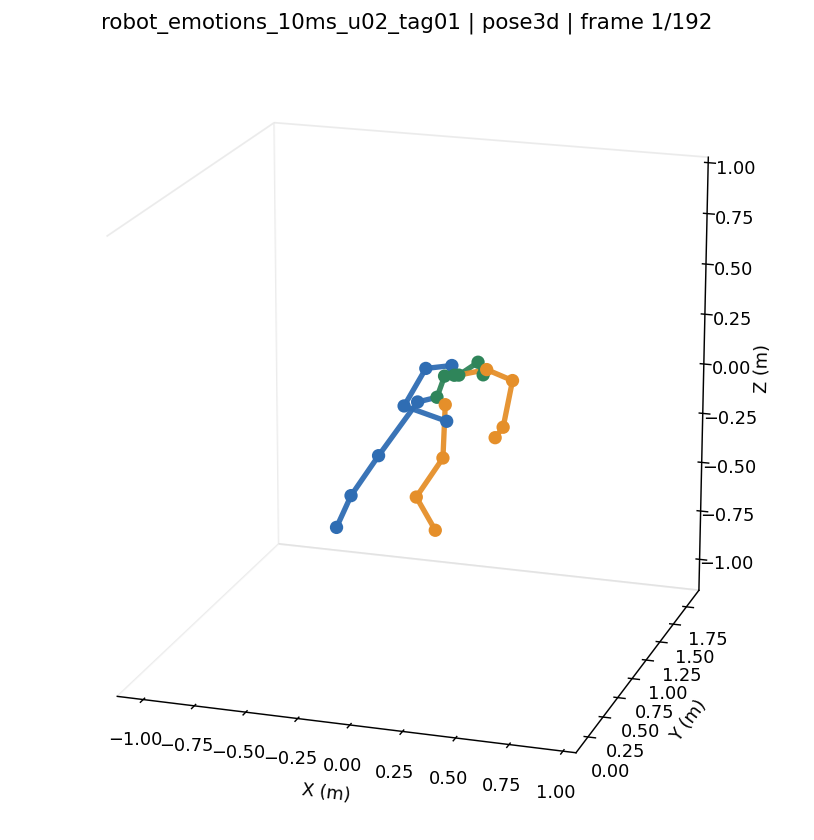

In [6]:
preview_index = int(np.clip(PREVIEW_FRAME, 0, len(RENDER_POINTS) - 1))
preview_frame_number = int(render_frame_indices[preview_index])

preview_trail = None
if SEQUENCE['coordinate_space'] != 'body_metric_local' and not CENTER_ON_ROOT:
    preview_trail = ROOT_POINTS[: preview_index + 1]

fig = plt.figure(figsize=FIGSIZE, dpi=DPI)
ax = fig.add_subplot(111, projection='3d')
draw_pose_frame(
    ax,
    RENDER_POINTS[preview_index],
    SEQUENCE['skeleton_parents'],
    SEQUENCE['joint_names_3d'],
    limits=SCENE_LIMITS,
    title=(
        f"{SEQUENCE['clip_id']} | {POSE_LABEL} | "
        f"frame {preview_frame_number + 1}/{SEQUENCE['num_frames']}"
    ),
    annotate=SHOW_JOINT_NAMES,
    trail_points=preview_trail,
)
plt.show()


In [7]:
def figure_to_rgb_array(fig) -> np.ndarray:
    fig.canvas.draw()
    rgba = np.asarray(fig.canvas.buffer_rgba(), dtype=np.uint8)
    return np.array(rgba[..., :3], copy=True)


def render_pose_video(output_path: str | Path) -> Path:
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    fig = plt.figure(figsize=FIGSIZE, dpi=DPI)
    ax = fig.add_subplot(111, projection='3d')
    render_fps = max(1.0, SEQUENCE['fps'] / max(FRAME_STEP, 1))
    trail_window = max(2, int(round(TRAIL_SECONDS * render_fps)))

    with imageio.get_writer(
        output_path,
        fps=render_fps,
        codec='libx264',
        quality=7,
        ffmpeg_log_level='error',
    ) as writer:
        for local_index, frame_points in enumerate(RENDER_POINTS):
            frame_number = int(render_frame_indices[local_index])

            trail_points = None
            if SEQUENCE['coordinate_space'] != 'body_metric_local' and not CENTER_ON_ROOT:
                trail_start = max(0, local_index - trail_window + 1)
                trail_points = ROOT_POINTS[trail_start : local_index + 1]

            title = (
                f"{SEQUENCE['clip_id']} | {POSE_LABEL} | "
                f"frame {frame_number + 1}/{SEQUENCE['num_frames']} | "
                f"t={RENDER_TIMESTAMPS[local_index]:.2f}s"
            )
            draw_pose_frame(
                ax,
                frame_points,
                SEQUENCE['skeleton_parents'],
                SEQUENCE['joint_names_3d'],
                limits=SCENE_LIMITS,
                title=title,
                annotate=SHOW_JOINT_NAMES,
                trail_points=trail_points,
            )
            writer.append_data(figure_to_rgb_array(fig))

    plt.close(fig)
    return output_path


rendered_path = render_pose_video(OUT_VIDEO)
print(f'Video salvo em: {format_path(rendered_path)}')


Video salvo em: output/robot_emotions_t2mgpt/notebook_renders/robot_emotions_10ms_u02_tag01_pose3d.mp4


In [8]:
display(Video(str(rendered_path), embed=True))


## Notas

- `POSE_VARIANT='pose3d'` usa a saida pseudo-global final, com deslocamento global do root.
- `POSE_VARIANT='metric_local'` ajuda a inspecionar o gesto sem locomocao global.
- `POSE_VARIANT='prompt_raw'` aproxima mais a saida adaptada logo apos o backend `t2mgpt`.
- `CENTER_ON_ROOT=True` deixa a camera mais estavel para comparar apenas o gesto.
- `FRAME_STEP` e `MAX_RENDER_FRAMES` sao uteis para depuracao rapida antes de renderizar o video completo.
